In [ ]:
#Beam Dump Studies
#Flux Histograms SBND (off-target) G4BNB DAR-enabled

In [43]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import uproot
import awkward as ak
import math

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

In [44]:
file = uproot.open('/Users/mnebotg/Software/future_runing/beamdump/hists_sbnd_offTarg_v111.root')
for key in file.keys():
    print(key, file[key].classname, file[key].title)
#file.keys()
#file.classnames()
#file.title_of('h501;1')
#file['h501;1'].all_members

h_xyE;1 TH3F Neutrino vertices at r=(74.780000,0.000000,11000.000000)cm
h501;1 TH1F #nu_{e} (all)
h511;1 TH1F ...->#mu^{#pm}->#nu_{e}
h521;1 TH1F ...->#pi^{#pm}->#nu_{e}
h531;1 TH1F ...->K^{0}_{L}->#nu_{e}
h541;1 TH1F ...->K^{#pm}->#nu_{e}
h502;1 TH1F #bar{#nu}_{e} (all)
h512;1 TH1F ...->#mu^{#pm}->#bar{#nu}_{e}
h522;1 TH1F ...->#pi^{#pm}->#bar{#nu}_{e}
h532;1 TH1F ...->K^{0}_{L}->#bar{#nu}_{e}
h542;1 TH1F ...->K^{#pm}->#bar{#nu}_{e}
h503;1 TH1F #nu_{#mu} (all)
h513;1 TH1F ...->#mu^{#pm}->#nu_{#mu}
h523;1 TH1F ...->#pi^{#pm}->#nu_{#mu}
h533;1 TH1F ...->K^{0}_{L}->#nu_{#mu}
h543;1 TH1F ...->K^{#pm}->#nu_{#mu}
h504;1 TH1F #bar{#nu}_{#mu} (all)
h514;1 TH1F ...->#mu^{#pm}->#bar{#nu}_{#mu}
h524;1 TH1F ...->#pi^{#pm}->#bar{#nu}_{#mu}
h534;1 TH1F ...->K^{0}_{L}->#bar{#nu}_{#mu}
h544;1 TH1F ...->K^{#pm}->#bar{#nu}_{#mu}
h701;1 TH1F #nu_{e} (all)
h711;1 TH1F pBe->#pi^{#pm}->...->#mu^{#pm}->#nu_{e}
h721;1 TH1F pBe->#pi^{#pm}->..(not #mu^{#pm})..->#nu_{e}
h731;1 TH1F pBe->K^{0}_{L}->...->#nu_{e}


In [46]:

# Flavour map
flavours = {
    "nue":  {"code": "1", "label": r"$\nu_e$"},
    "anue":  {"code": "2", "label": r"$\bar{\nu}_e$"},
    "numu":  {"code": "3", "label": r"$\nu_\mu$"},
    "anumu": {"code": "4", "label": r"$\bar{\nu}_\mu$"},
}
# Parent contribution prefixes
parents = {
    "all":  {"code": "50", "label": "All"},
    "mu":   {"code": "51", "label": r"$\mu^{\pm}$"},
    "pi":   {"code": "52", "label": r"$\pi^{\pm}$"},
    "K0L":  {"code": "53", "label": r"$K^0_L$"},
    "Kpm":  {"code": "54", "label": r"$K^{\pm}$"},
}

# Get histogram objects first
# Container dictionaries
hists = {}
flux  = {}

for flav_name, flav_idx in flavours.items():
    for parent_name, parent_prefix in parents.items():
        
        hist_name = f"h{parent_prefix['code']}{flav_idx['code']}"
        
        # Load histogram
        h = file[hist_name]
        
        # Store histogram object
        hists[f"{flav_name}_{parent_name}"] = h
        
        # Store values
        flux[f"{flav_name}_{parent_name}"] = h.values()
        

# Get bin edges (assume same binning for all)
edges = h_nue.axes[0].edges()

# Compute bin width (uniform binning assumed)
bin_width = edges[1] - edges[0]

print(np.allclose(np.diff(edges), edges[1] - edges[0])) #("Check:Are Bin edges uniformly spaced?")

print(list(flux.keys()))
print(len(flux["nue_all"]))

True
['nue_all', 'nue_mu', 'nue_pi', 'nue_K0L', 'nue_Kpm', 'anue_all', 'anue_mu', 'anue_pi', 'anue_K0L', 'anue_Kpm', 'numu_all', 'numu_mu', 'numu_pi', 'numu_K0L', 'numu_Kpm', 'anumu_all', 'anumu_mu', 'anumu_pi', 'anumu_K0L', 'anumu_Kpm']
200


In [37]:
bins = np.linspace(0, 10, 201)
# bins

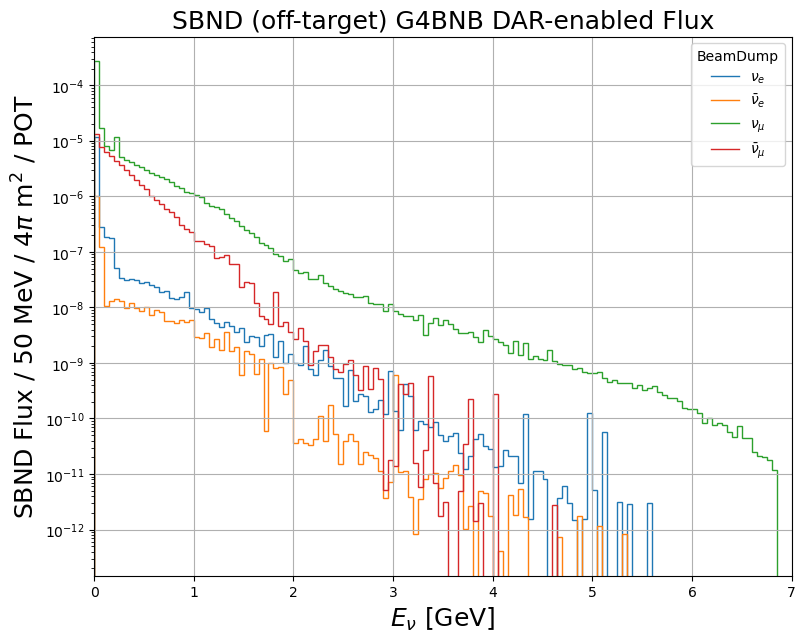

In [47]:
#Josie's flux
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(9, 7))

ax.stairs(flux["nue_all"], bins, label=r'$\nu_e$')
ax.stairs(flux["anue_all"], bins, label=r'$\bar{\nu}_e$')
ax.stairs(flux["numu_all"], bins, label=r'$\nu_\mu$')
ax.stairs(flux["anumu_all"], bins, label=r'$\bar{\nu}_{\mu}$')

ax.legend(title='BeamDump')
ax.set_xlim([0, 7])
ax.set_yscale('log')
ax.set_xlabel(r'$E_\nu$ [GeV]', fontsize=18)
ax.set_ylabel(r'SBND Flux / 50 MeV / 4$\pi$ m$^2$ / POT', fontsize=18)
#The flux is not per unit area, it is for an approximated SBND front face circle with a radius of 2m, so an area of 4pi m^2
ax.set_title('SBND (off-target) G4BNB DAR-enabled Flux', fontsize=18)
ax.grid(True)

#plt.Show()

In [48]:
# Parents contributing to each flavour (excluding "all")
parent_list = ["mu", "pi", "K0L", "Kpm"]

grouped_flux = {}

for flav in ["nue", "anue", "numu", "anumu"]:
    grouped_flux[flav] = sum(flux[f"{flav}_{p}"] for p in parent_list)



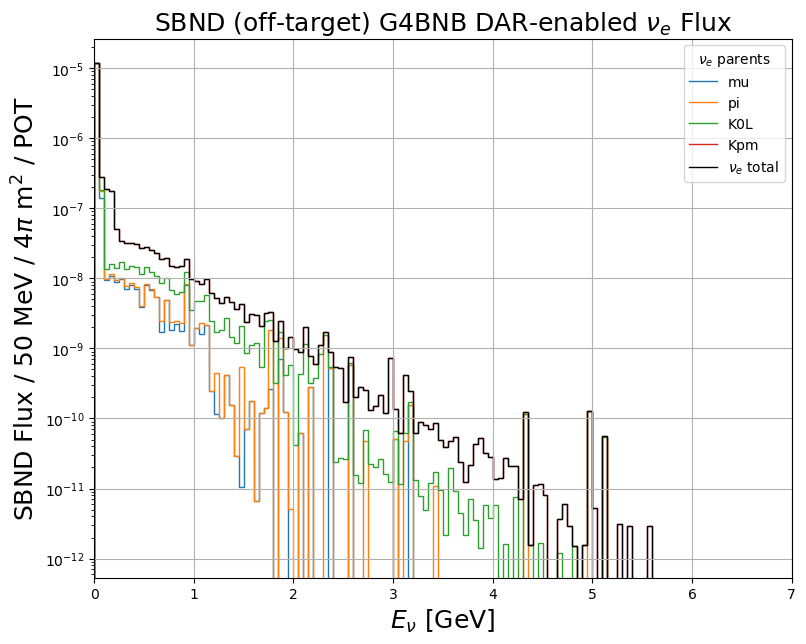

In [54]:
fig, ax = plt.subplots(figsize=(9, 7))

bottom = np.zeros_like(flux["nue_mu"])

for parent in parent_list:
    vals = flux[f"nue_{parent}"]
    ax.stairs(vals + bottom, bins, label=parent)
    bottom += vals

ax.stairs(bottom,bins,color="black",linewidth=1,label=r'$\nu_e$ total'
)
ax.legend(title=r'$\nu_e$ parents')
ax.set_yscale("log")
ax.set_xlim([0, 7])
ax.set_xlabel(r'$E_\nu$ [GeV]', fontsize=18)
ax.set_ylabel(r'SBND Flux / 50 MeV / 4$\pi$ m$^2$ / POT', fontsize=18)
#The flux is not per unit area, it is for an approximated SBND front face circle with a radius of 2m, so an area of 4pi m^2
ax.set_title(r'SBND (off-target) G4BNB DAR-enabled $\nu_e$ Flux', fontsize=18)
ax.grid(True)


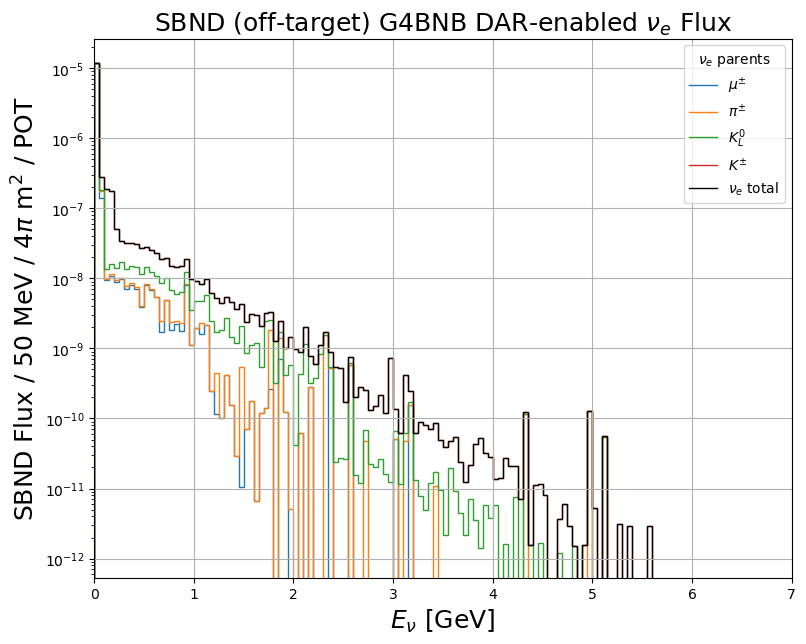

In [55]:
fig, ax = plt.subplots(figsize=(9, 7))

bottom = np.zeros_like(flux["nue_mu"])

for parent in parent_list:
    vals = flux[f"nue_{parent}"]
    label = parents[parent]["label"]    
    ax.stairs(vals + bottom, bins, label=label)
    bottom += vals

ax.stairs(bottom,bins,color="black",linewidth=1,label=r'$\nu_e$ total'
)
ax.legend(title=r'$\nu_e$ parents')
ax.set_yscale("log")
ax.set_xlim([0, 7])
ax.set_xlabel(r'$E_\nu$ [GeV]', fontsize=18)
ax.set_ylabel(r'SBND Flux / 50 MeV / 4$\pi$ m$^2$ / POT', fontsize=18)
#The flux is not per unit area, it is for an approximated SBND front face circle with a radius of 2m, so an area of 4pi m^2
ax.set_title(r'SBND (off-target) G4BNB DAR-enabled $\nu_e$ Flux', fontsize=18)
ax.grid(True)


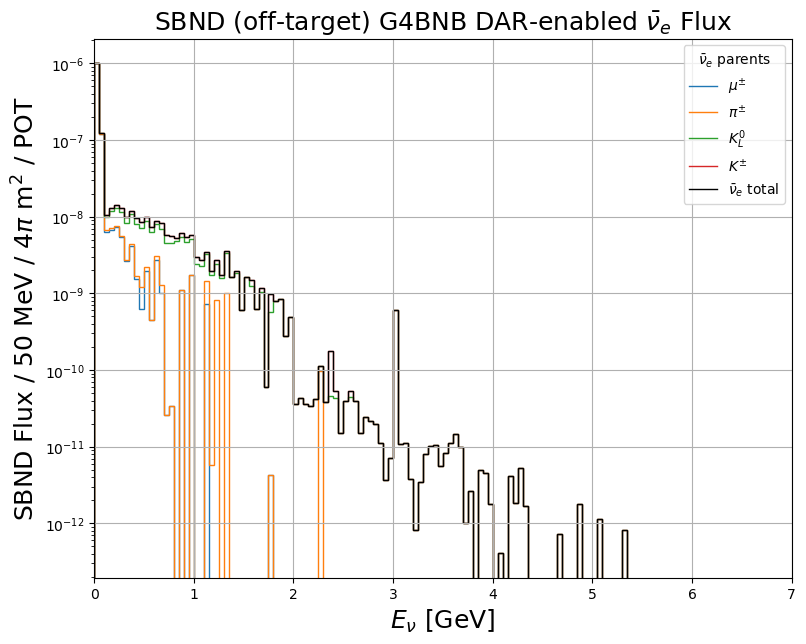

In [56]:
fig, ax = plt.subplots(figsize=(9, 7))

bottom = np.zeros_like(flux["anue_mu"])

for parent in parent_list:
    vals = flux[f"anue_{parent}"]
    label = parents[parent]["label"]    
    ax.stairs(vals + bottom, bins, label=label)
    bottom += vals

ax.stairs(bottom,bins,color="black",linewidth=1,label=r'$\bar{\nu}_e$ total'
)
ax.legend(title=r'$\bar{\nu}_e$ parents')
ax.set_yscale("log")
ax.set_xlim([0, 7])
ax.set_xlabel(r'$E_\nu$ [GeV]', fontsize=18)
ax.set_ylabel(r'SBND Flux / 50 MeV / 4$\pi$ m$^2$ / POT', fontsize=18)
#The flux is not per unit area, it is for an approximated SBND front face circle with a radius of 2m, so an area of 4pi m^2
ax.set_title(r'SBND (off-target) G4BNB DAR-enabled $\bar{\nu}_e$ Flux', fontsize=18)
ax.grid(True)


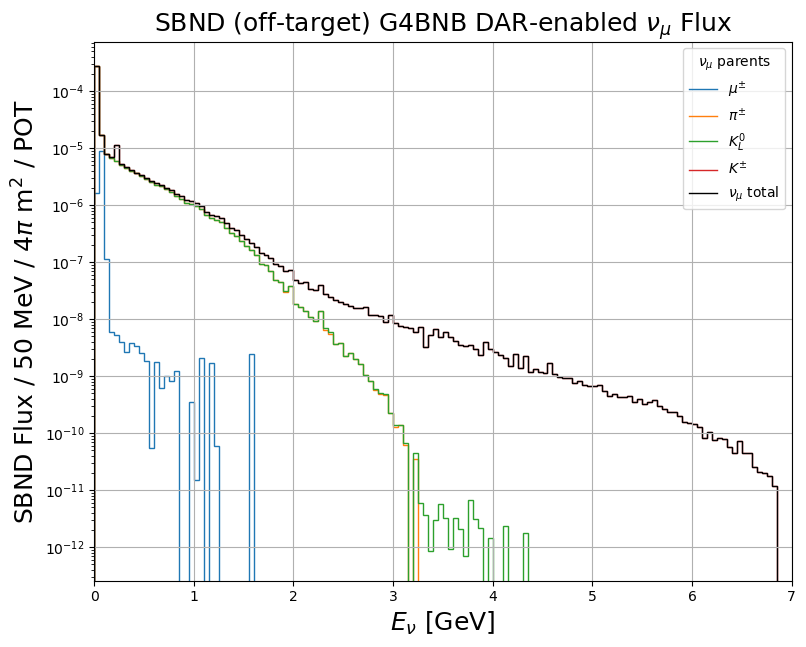

In [57]:
fig, ax = plt.subplots(figsize=(9, 7))

bottom = np.zeros_like(flux["numu_mu"])

for parent in parent_list:
    vals = flux[f"numu_{parent}"]
    label = parents[parent]["label"]    
    ax.stairs(vals + bottom, bins, label=label)
    bottom += vals

ax.stairs(bottom,bins,color="black",linewidth=1,label=r'$\nu_\mu$ total'
)
ax.legend(title=r'$\nu_\mu$ parents')
ax.set_yscale("log")
ax.set_xlim([0, 7])
ax.set_xlabel(r'$E_\nu$ [GeV]', fontsize=18)
ax.set_ylabel(r'SBND Flux / 50 MeV / 4$\pi$ m$^2$ / POT', fontsize=18)
#The flux is not per unit area, it is for an approximated SBND front face circle with a radius of 2m, so an area of 4pi m^2
ax.set_title(r'SBND (off-target) G4BNB DAR-enabled $\nu_\mu$ Flux', fontsize=18)
ax.grid(True)


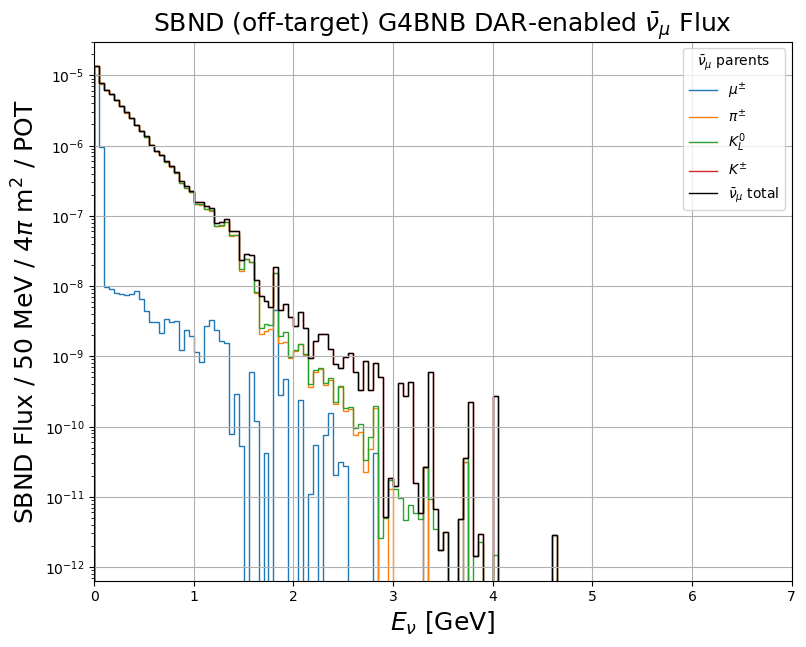

In [59]:
fig, ax = plt.subplots(figsize=(9, 7))

bottom = np.zeros_like(flux["anumu_mu"])

for parent in parent_list:
    vals = flux[f"anumu_{parent}"]
    label = parents[parent]["label"]    
    ax.stairs(vals + bottom, bins, label=label)
    bottom += vals

ax.stairs(bottom,bins,color="black",linewidth=1,label=r'$\bar{\nu}_\mu$ total'
)
ax.legend(title=r'$\bar{\nu}_\mu$ parents')
ax.set_yscale("log")
ax.set_xlim([0, 7])
ax.set_xlabel(r'$E_\nu$ [GeV]', fontsize=18)
ax.set_ylabel(r'SBND Flux / 50 MeV / 4$\pi$ m$^2$ / POT', fontsize=18)
#The flux is not per unit area, it is for an approximated SBND front face circle with a radius of 2m, so an area of 4pi m^2
ax.set_title(r'SBND (off-target) G4BNB DAR-enabled $\bar{\nu}_\mu$ Flux', fontsize=18)
ax.grid(True)
